# Importacion de librerias y conexión

In [1]:
import mysql.connector
import pandas as pd
import numpy as np
import regex as re
from datetime import datetime
from rapidfuzz import fuzz
import os
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# --------------------------
# Configuración
# --------------------------
CARPETA = r"C:\Users\Usuario\Desktop\E19\ProjecteData\Equip_19\Data\INE"

# --------------------------
# Funciones
# --------------------------
def extraer_año(nombre):
    import re
    m = re.search(r'(\d{4})', nombre)
    return int(m.group(1)) if m else None

def renombrar_columnas_criticas(df):
    """
    Unifica nombres de columnas críticas sin tocar los valores.
    """
    col_map = {}
    for c in df.columns:
        cn = str(c).lower()
        if "provinc" in cn:
            col_map[c] = "provincia"
        elif ("pais" in cn and "resid" in cn) or ("residencia" in cn):
            col_map[c] = "pais_residencia"
        elif "mes" in cn:
            col_map[c] = "mes"
        elif "total" in cn or "viajer" in cn or "pernoct" in cn:
            col_map[c] = "total"
    df = df.rename(columns=col_map)
    return df

def leer_csv(ruta):
    for enc in ["utf-8", "utf-8-sig", "latin1", "cp1252"]:
        try:
            df = pd.read_csv(ruta, sep=";", encoding=enc, engine="python")
            # Normalizar miles con coma a float
            for col in df.columns:
                if df[col].dtype == object:
                    df[col] = df[col].str.replace(".", "", regex=False)\
                                     .str.replace(",", ".", regex=False)
            return df
        except:
            continue
    raise ValueError(f"No se pudo leer {ruta}")

# --------------------------
# 1) PROCESAR HOTELES
# --------------------------
hoteles_perno = []
hoteles_viaj = []

for archivo in os.listdir(CARPETA):
    ruta = os.path.join(CARPETA, archivo)
    if not archivo.lower().endswith(".csv"):
        continue
    anio = extraer_año(archivo)
    df = leer_csv(ruta)
    df = renombrar_columnas_criticas(df)

    # asegurar columnas críticas
    for c in ["provincia","pais_residencia","mes","total"]:
        if c not in df.columns:
            df[c] = pd.NA
    df["año"] = anio

    if "hoteles_pernoctaciones" in archivo.lower():
        df["pernoctaciones"] = pd.to_numeric(df["total"], errors="coerce")
        df_hot = df[["año","mes","provincia","pais_residencia","pernoctaciones"]].copy()
        hoteles_perno.append(df_hot)
    elif "hoteles_viajeros" in archivo.lower():
        df["total_viajeros"] = pd.to_numeric(df["total"], errors="coerce")
        df_hotv = df[["año","mes","provincia","pais_residencia","total_viajeros"]].copy()
        hoteles_viaj.append(df_hotv)

# unir hoteles pernoctaciones y viajeros
if hoteles_perno:
    df_hoteles = pd.concat(hoteles_perno, ignore_index=True)
    if hoteles_viaj:
        df_hoteles = df_hoteles.merge(
            pd.concat(hoteles_viaj, ignore_index=True),
            on=["año","mes","provincia","pais_residencia"],
            how="left"
        )
    df_hoteles["tipo_acomodacion"] = "hoteles"
else:
    df_hoteles = pd.DataFrame(columns=["año","mes","provincia","pais_residencia","pernoctaciones","total_viajeros","tipo_acomodacion"])


# --------------------------
# 2) PROCESAR APARTAMENTOS
# --------------------------

apart_viaj = []
apart_perno = []

for archivo in os.listdir(CARPETA):
    ruta = os.path.join(CARPETA, archivo)
    if not archivo.lower().endswith(".csv"):
        continue
    anio = extraer_año(archivo)
    df = leer_csv(ruta)
    df = renombrar_columnas_criticas(df)
    df["año"] = anio

    # viajeros
    if "apartamentos_viajeros" in archivo.lower():
        apart_viaj.append(df)

    # pernoctaciones (media)
    if "apartamentos_pernoctaciones" in archivo.lower():
        apart_perno.append(df)

# ---- unir viajeros ----
df_apart_viaj = pd.concat(apart_viaj, ignore_index=True) if apart_viaj else None
if df_apart_viaj is not None:
    df_apart_viaj["total_viajeros"] = pd.to_numeric(df_apart_viaj["total"], errors="coerce")

# ---- unir pernoctaciones ----
df_apart_perno = pd.concat(apart_perno, ignore_index=True) if apart_perno else None
if df_apart_perno is not None:
    df_apart_perno["pernoctaciones"] = pd.to_numeric(df_apart_perno["total"], errors="coerce")

# ---- MERGE FINAL ----
df_apart = df_apart_viaj.merge(
    df_apart_perno[["año","mes","provincia","pernoctaciones"]],
    on=["año","mes","provincia"],
    how="left"
)

df_apart["tipo_acomodacion"] = "apartamentos"
df_apart = df_apart[["año","mes","provincia","pais_residencia",
                     "pernoctaciones","total_viajeros","tipo_acomodacion"]]

# --------------------------
# 3) UNIR TODO
# --------------------------
df_final = pd.concat([df_hoteles, df_apart], ignore_index=True)
columnas_finales = ["año","mes","tipo_acomodacion","provincia","pais_residencia","pernoctaciones","total_viajeros"]
df_final = df_final[columnas_finales]

# --------------------------
# 4) RESULTADO
# --------------------------
df_final.head()


,año,mes,tipo_acomodacion,provincia,pais_residencia,pernoctaciones,total_viajeros
0,2015,Enero,hoteles,Balears. Illes,Residentes en España,2.34,21058.0
1,2015,Febrero,hoteles,Balears. Illes,Residentes en España,3.75,48484.0
2,2015,Marzo,hoteles,Balears. Illes,Residentes en España,4.76,64934.0
3,2015,Abril,hoteles,Balears. Illes,Residentes en España,4.56,107273.0
4,2015,Mayo,hoteles,Balears. Illes,Residentes en España,3.41,123634.0


In [3]:
df_final.isnull().sum()

año                    0
mes                    0
tipo_acomodacion       0
provincia              0
pais_residencia        0
pernoctaciones       260
total_viajeros      2470
dtype: int64

In [4]:
df_final

,año,mes,tipo_acomodacion,provincia,pais_residencia,pernoctaciones,total_viajeros
0,2015,Enero,hoteles,Balears. Illes,Residentes en España,2.34,21058.0
1,2015,Febrero,hoteles,Balears. Illes,Residentes en España,3.75,48484.0
2,2015,Marzo,hoteles,Balears. Illes,Residentes en España,4.76,64934.0
3,2015,Abril,hoteles,Balears. Illes,Residentes en España,4.56,107273.0
4,2015,Mayo,hoteles,Balears. Illes,Residentes en España,3.41,123634.0
...,...,...,...,...,...,...,...
16459,2021,Agosto,apartamentos,46 Valencia/València,Resto del mundo,7.40,1408.0
16460,2021,Septiembre,apartamentos,46 Valencia/València,Resto del mundo,5.22,1257.0
16461,2021,Octubre,apartamentos,46 Valencia/València,Resto del mundo,4.67,1087.0
16462,2021,Noviembre,apartamentos,46 Valencia/València,Resto del mundo,7.89,1279.0


## Tratamiento de nulos

In [5]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16464 entries, 0 to 16463
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   año               16464 non-null  int64  
 1   mes               16464 non-null  object 
 2   tipo_acomodacion  16464 non-null  object 
 3   provincia         16464 non-null  object 
 4   pais_residencia   16464 non-null  object 
 5   pernoctaciones    16204 non-null  float64
 6   total_viajeros    13994 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 900.5+ KB


In [6]:
df_final.isnull().sum()

año                    0
mes                    0
tipo_acomodacion       0
provincia              0
pais_residencia        0
pernoctaciones       260
total_viajeros      2470
dtype: int64

In [7]:
# Si viajeros = 0 → media_pernoctaciones = 0
df_final['pernoctaciones'] = df_final['pernoctaciones'].mask(
    df_final['total_viajeros'] == 0,
    0
)

# Interpolación mes a mes dentro de cada provincia
df_final = df_final.sort_values(['provincia','año','mes'])
df_final['pernoctaciones'] = df_final.groupby('provincia')['pernoctaciones'] \
                                           .transform(lambda x: x.interpolate(method='linear'))

# Si aún quedan NaN, rellenar con la media anual por provincia
df_final['pernoctaciones'] = df_final.groupby(['provincia','año'])['pernoctaciones'] \
                                           .transform(lambda x: x.fillna(x.mean()))

In [8]:
# Imputar 0 para total_viajeros sin dato

df_final['total_viajeros'] = df_final['total_viajeros'].fillna(0)

In [9]:
df_final.isnull().sum()

año                 0
mes                 0
tipo_acomodacion    0
provincia           0
pais_residencia     0
pernoctaciones      0
total_viajeros      0
dtype: int64

## Estandarización de texto

In [10]:
datosp = sorted([str(x) for x in df_final["provincia"].unique()])

for i in range(len(datosp)):
    for j in range(i+1, len(datosp)):
        score = fuzz.ratio(datosp[i], datosp[j])
        if score > 85:
            print(f"{score:.1f}% - '{datosp[i]}' vs '{datosp[j]}'")


90.3% - '07 Balears. Illes' vs 'Balears. Illes'
85.7% - '08 Barcelona' vs 'Barcelona'
91.9% - '46 Valencia/València' vs 'Valencia/València'
86.5% - '46 Valencia/València' vs 'Valencia/Valéncia'
94.1% - 'Valencia/València' vs 'Valencia/Valéncia'


In [11]:
df_final["provincia"] = df_final["provincia"].replace(['Balears. Illes', '07 Balears. Illes'], 'Islas Baleares').replace('08 Barcelona', 'Barcelona').replace([
    "46 Valencia/València","Valencia/València","Valencia/Valéncia"], "Valencia").replace('17 Girona', 'Girona').replace('28 Madrid', 'Madrid').replace(
        '41 Sevilla', 'Sevilla').replace('29 Málaga', 'Málaga')

In [12]:
df_final["provincia"].unique()

array(['Islas Baleares', 'Barcelona', 'Girona', 'Madrid', 'Málaga',
       'Sevilla', 'Valencia'], dtype=object)

In [13]:
datosta = sorted([str(x) for x in df_final["tipo_acomodacion"].unique()])

for i in range(len(datosta)):
    for j in range(i+1, len(datosta)):
        score = fuzz.ratio(datosta[i], datosta[j])
        if score > 85:
            print(f"{score:.1f}% - '{datosta[i]}' vs '{datosta[j]}'")

In [14]:
df_final.columns

Index(['año', 'mes', 'tipo_acomodacion', 'provincia', 'pais_residencia',
       'pernoctaciones', 'total_viajeros'],
      dtype='object')

In [15]:
df_final["tipo_acomodacion"].unique()

array(['hoteles', 'apartamentos'], dtype=object)

In [16]:
datospr = sorted([str(x) for x in df_final["pais_residencia"].unique()])

for i in range(len(datospr)):
    for j in range(i+1, len(datospr)):
        score = fuzz.ratio(datospr[i], datospr[j])
        if score > 85:
            print(f"{score:.1f}% - '{datospr[i]}' vs '{datospr[j]}'")

88.4% - 'No residentes en España' vs 'Residentes en España'


In [17]:
df_final["pais_residencia"] = df_final["pais_residencia"].replace('Países Africanos', 'Países africanos').replace('Republica Checa', 'República Checa').replace(
    ['Residentes en España', 'Españoles'], 'España'
)

In [18]:
df_final["pais_residencia"].unique()

array(['España', 'No residentes en España', 'Alemania', 'Austria',
       'Bélgica', 'Dinamarca', 'Finlandia', 'Francia', 'Grecia',
       'Irlanda', 'Italia', 'Luxemburgo', 'Países Bajos', 'Polonia',
       'Portugal', 'Reino Unido', 'República Checa', 'Suecia',
       'Resto de la UE', 'Noruega', 'Rusia', 'Suiza', 'Resto de Europa',
       'Estados Unidos', 'Resto de América', 'Países africanos',
       'Resto del mundo'], dtype=object)

In [19]:
df_final

,año,mes,tipo_acomodacion,provincia,pais_residencia,pernoctaciones,total_viajeros
507,2018,Abril,hoteles,Islas Baleares,España,3.96,94236.0
519,2018,Abril,hoteles,Islas Baleares,No residentes en España,5.35,0.0
7731,2018,Abril,apartamentos,Islas Baleares,España,5.55,17719.0
7743,2018,Abril,apartamentos,Islas Baleares,Alemania,5.55,78892.0
7755,2018,Abril,apartamentos,Islas Baleares,Austria,5.55,1173.0
...,...,...,...,...,...,...,...
7676,2017,Septiembre,apartamentos,Valencia,Resto de Europa,5.63,960.0
7688,2017,Septiembre,apartamentos,Valencia,Estados Unidos,5.63,1224.0
7700,2017,Septiembre,apartamentos,Valencia,Resto de América,5.63,1927.0
7712,2017,Septiembre,apartamentos,Valencia,Países africanos,5.63,421.0


In [20]:
filtro = ["Resto de la UE", "Resto de Europa", "Resto de Europa sin U.E"]

df_filtrado = df_final[df_final["pais_residencia"].isin(filtro)]

print(df_filtrado["pais_residencia"].unique())
df_filtrado

['Resto de la UE' 'Resto de Europa']


,año,mes,tipo_acomodacion,provincia,pais_residencia,pernoctaciones,total_viajeros
7935,2018,Abril,apartamentos,Islas Baleares,Resto de la UE,5.55,4194.0
7983,2018,Abril,apartamentos,Islas Baleares,Resto de Europa,5.55,1043.0
7939,2018,Agosto,apartamentos,Islas Baleares,Resto de la UE,7.18,18998.0
7987,2018,Agosto,apartamentos,Islas Baleares,Resto de Europa,7.18,9625.0
7943,2018,Diciembre,apartamentos,Islas Baleares,Resto de la UE,7.01,406.0
...,...,...,...,...,...,...,...
7678,2017,Noviembre,apartamentos,Valencia,Resto de Europa,3.65,1489.0
7629,2017,Octubre,apartamentos,Valencia,Resto de la UE,4.37,1894.0
7677,2017,Octubre,apartamentos,Valencia,Resto de Europa,4.37,554.0
7628,2017,Septiembre,apartamentos,Valencia,Resto de la UE,5.63,5151.0


In [21]:
for archivo in os.listdir(CARPETA):
    if archivo.lower().endswith(".csv") and "hoteles_pernoctaciones" in archivo.lower():
        df = leer_csv(os.path.join(CARPETA, archivo))
        print(f"{archivo}: {df.columns.tolist()}")

hoteles_pernoctaciones_2015.csv: ['Provincias', 'Residencia', 'Meses', 'Total']
hoteles_pernoctaciones_2016.csv: ['Provincias', 'Residencia', 'Meses', 'Total']
hoteles_pernoctaciones_2017.csv: ['Provincias', 'Residencia', 'Meses', 'Total']
hoteles_pernoctaciones_2018.csv: ['Provincias', 'Residencia', 'Meses', 'Total']
hoteles_pernoctaciones_2019.csv: ['Provincias', 'Residencia', 'Meses', 'Total']
hoteles_pernoctaciones_2020.csv: ['Provincias', 'Residencia', 'Meses', 'Total']
hoteles_pernoctaciones_2021.csv: ['Provincias', 'Residencia', 'Meses', 'Total']


In [22]:
df_filtrado = df_final[
    (df_final["año"] == 2015) &
    (df_final["provincia"].str.contains("Islas Baleares", case=False, na=False))
][["año","provincia","pernoctaciones","total_viajeros"]]

df_filtrado


,año,provincia,pernoctaciones,total_viajeros
3,2015,Islas Baleares,4.56,107273.0
15,2015,Islas Baleares,5.45,0.0
1179,2015,Islas Baleares,6.26,6157.0
1191,2015,Islas Baleares,6.26,12576.0
1203,2015,Islas Baleares,6.26,199.0
...,...,...,...,...
1436,2015,Islas Baleares,7.50,658.0
1448,2015,Islas Baleares,7.50,839.0
1460,2015,Islas Baleares,7.50,748.0
1472,2015,Islas Baleares,7.50,195.0


In [23]:
filtro_calendario = ['Barcelona','Madrid','Valencia']
df_calendario = df_final[df_final['provincia'].isin(filtro_calendario)]
df_calendario.head(50)

,año,mes,tipo_acomodacion,provincia,pais_residencia,pernoctaciones,total_viajeros
531,2018,Abril,hoteles,Barcelona,España,2.04,279387.0
543,2018,Abril,hoteles,Barcelona,No residentes en España,2.64,0.0
8043,2018,Abril,apartamentos,Barcelona,España,6.22,73831.0
8055,2018,Abril,apartamentos,Barcelona,Alemania,6.22,6032.0
8067,2018,Abril,apartamentos,Barcelona,Austria,6.22,670.0
8079,2018,Abril,apartamentos,Barcelona,Bélgica,6.22,1826.0
8091,2018,Abril,apartamentos,Barcelona,Dinamarca,6.22,967.0
8103,2018,Abril,apartamentos,Barcelona,Finlandia,6.22,648.0
8115,2018,Abril,apartamentos,Barcelona,Francia,6.22,11589.0
8127,2018,Abril,apartamentos,Barcelona,Grecia,6.22,483.0


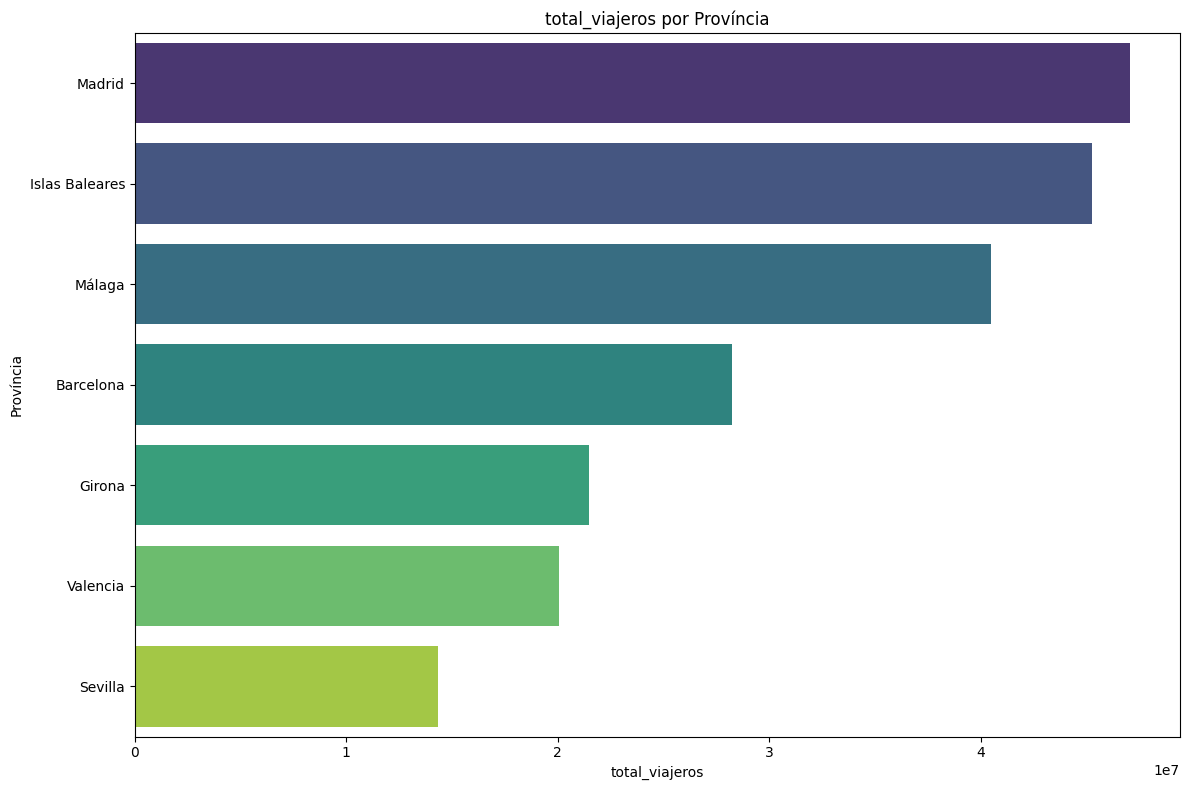

In [24]:
import seaborn as sns

colunas_requeridas = ['provincia', 'pais_residencia', 'pernoctaciones', 'total_viajeros']
for col in colunas_requeridas:
    if col not in df_final.columns:
        print(f"Erro: Coluna '{col}' não encontrada no df_final.")

# Gráfico 1: Distribuição de Pernoctações por Província
pernoctaciones_por_provincia = df_final.groupby('provincia')['total_viajeros'].sum().reset_index()
pernoctaciones_por_provincia = pernoctaciones_por_provincia.dropna(subset=['total_viajeros'])
pernoctaciones_por_provincia['total_viajeros'] = pd.to_numeric(pernoctaciones_por_provincia['total_viajeros'], errors='coerce')
pernoctaciones_por_provincia = pernoctaciones_por_provincia.dropna(subset=['total_viajeros'])
pernoctaciones_por_provincia = pernoctaciones_por_provincia.sort_values(by='total_viajeros', ascending=False)

# Criar o gráfico de barras
plt.figure(figsize=(12, 8))
sns.barplot(data=pernoctaciones_por_provincia, x='total_viajeros', y='provincia', palette='viridis')
plt.title('total_viajeros por Província')
plt.xlabel('total_viajeros')
plt.ylabel('Província')
plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

## Exportacion de csv

In [25]:
df_final.to_csv('datos_INE_consolidados_17112025.csv', index=False)

___________________________________________

__________________________________________________________